## India Flight Data Analysis Python Project
Analysis and projections of various metrics (Airline, Destination, Arrival Time, etc) for flights in India from a Kaggle dataset using Python.

## Import Python Libraries
Importing Pandas, MatPlotLib.Pylot, and Seaborn for effective data maniuplation and visualization.

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Excel Data
Importing Excel Spreadsheet for Flight Data in India

In [96]:
df = pd.read_excel('airlines_flights_data(1).xlsx')

## Exploring Data Frames
Displaying data to understand data formmating and structure

In [97]:
df.info()
df.head(12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration (hrs)    300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price (INR ₹)     300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration (hrs),days_left,price (INR ₹)
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


## Data Cleaning
Checking for null or duplicate values

In [98]:
df[df.isnull().any(axis=1)] 
df[df.duplicated()] 
## No duplicates or null values found so no need to change original data frame.

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration (hrs),days_left,price (INR ₹)


## Removing Index Column
Index Column not necessary

In [99]:
df_cleaned = df.drop(columns=['index'])
df_cleaned.head(12)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration (hrs),days_left,price (INR ₹)
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


## Summary Statistics
Mean, Median, Quartiles, etc

In [100]:
df_cleaned.describe()

,duration (hrs),days_left,price (INR ₹)
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


## Adding Price ($) Column
Adding column that has price in USD.

In [101]:
df_cleaned['price (USD $)'] = (df_cleaned['price (INR ₹)'] * .012).round(2)
df_cleaned.head(12)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration (hrs),days_left,price (INR ₹),price (USD $)
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,71.44
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,71.44
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,71.47
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,71.46
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,71.46
5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955,71.46
6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060,72.72
7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060,72.72
8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954,71.45
9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954,71.45


## Adding Price per Hour Column
Adding column that has price per hour in USD.

In [102]:
df_cleaned['price per hour (USD $)'] = (df_cleaned['price (USD $)'] / df_cleaned['duration (hrs)']).round(2)
df_cleaned.head(12)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration (hrs),days_left,price (INR ₹),price (USD $),price per hour (USD $)
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,71.44,32.92
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,71.44,30.66
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,71.47,32.94
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,71.46,31.76
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,71.46,30.67
5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955,71.46,30.67
6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060,72.72,34.96
7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060,72.72,33.51
8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954,71.45,32.93
9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954,71.45,31.76


## Describe Function for Price Column and Price per Hour Column in USD
Checking average price of flights as well as average hourly price in USD for better understanding.

In [103]:
df_cleaned[['price (USD $)','price per hour (USD $)']].describe()

,price (USD $),price per hour (USD $)
count,300153.000000,300153.000000
mean,250.676072,26.105617
std,272.373277,32.801169
min,13.260000,1.240000
25%,57.400000,5.520000
50%,89.100000,11.740000
75%,510.250000,34.710000
max,1476.850000,341.680000


## Checking for outliers in Price Column
Seems that price above 75% quartile are outliers, let's check their rows to see if they're accurate.

In [104]:
print(df_cleaned[df_cleaned['price (USD $)'] > df_cleaned['price (USD $)'].quantile(0.75)].head(20).to_string())
## Looks like the reason for high prices is because the class is business class, which is often more expensive.

          airline  flight source_city departure_time stops arrival_time destination_city     class  duration (hrs)  days_left  price (INR ₹)  price (USD $)  price per hour (USD $)
206669  Air_India  AI-839       Delhi          Night   one        Night           Mumbai  Business           26.50          1          44450         533.40                   20.13
206670  Air_India  AI-544       Delhi        Evening   one        Night           Mumbai  Business            6.67          1          46690         560.28                   84.00
206671    Vistara  UK-985       Delhi        Evening  zero        Night           Mumbai  Business            2.17          1          50264         603.17                  277.96
206672  Air_India  AI-479       Delhi          Night   one    Afternoon           Mumbai  Business           17.75          1          50669         608.03                   34.26
206673  Air_India  AI-473       Delhi        Evening   one      Evening           Mumbai  Business  

## Accounting for Business Class Flights
Looks like the reason is because this includes business and econcomy tickets, so let's keep that in mind when doing our analysis. 


In [105]:
## Checking for all classes in the dataset
print(df_cleaned[df_cleaned['class'] == 'Economy'][['price (INR ₹)','price (USD $)', 'price per hour (USD $)']].describe().round(2))
print(df_cleaned[df_cleaned['class'] == 'Business'][['price (INR ₹)','price (USD $)', 'price per hour (USD $)']].describe().round(2))

       price (INR ₹)  price (USD $)  price per hour (USD $)
count      206666.00      206666.00               206666.00
mean         6572.34          78.87                    9.87
std          3743.52          44.92                    8.40
min          1105.00          13.26                    1.24
25%          4173.00          50.08                    4.45
50%          5772.00          69.26                    7.19
75%          7746.00          92.95                   12.48
max         42349.00         508.19                  134.65
       price (INR ₹)  price (USD $)  price per hour (USD $)
count       93487.00       93487.00                93487.00
mean        52540.08         630.48                   62.00
std         12969.31         155.63                   37.78
min         12000.00         144.00                   12.79
25%         45185.00         542.22                   35.10
50%         53164.00         637.97                   50.74
75%         60396.00         724.75     

## Still seeing outliers near the maximum values, let's take a closer look.
Going to make a line plot to see at prices the outliers are occurring.

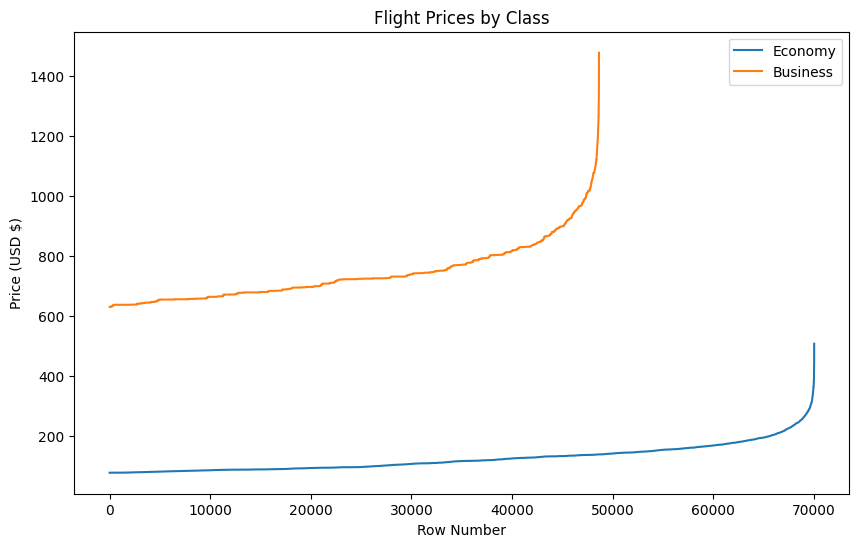

In [106]:
economy_prices  = df_cleaned[(df_cleaned['class'] == 'Economy') & (df_cleaned['price (USD $)'] > 78.87)]['price (USD $)'].sort_values().reset_index(drop=True)
business_prices = df_cleaned[(df_cleaned['class'] == 'Business') & (df_cleaned['price (USD $)'] > 630.78)]['price (USD $)'].sort_values().reset_index(drop=True)

plt.figure(figsize=(10,6))
plt.plot(range(len(economy_prices)), economy_prices, label='Economy')
plt.plot(range(len(business_prices)), business_prices, label='Business')

plt.xlabel('Row Number')
plt.ylabel('Price (USD $)')
plt.title('Flight Prices by Class')
plt.legend()
plt.show()



## Removing Outliers
Based on chart above, economy tickets over 200 are clear outliers and business price tickets over 800 are clear outliers. Let's remove them from our data.

In [107]:
df_cleaned = df_cleaned.drop(df_cleaned[(df_cleaned['class'] == 'Economy') & (df_cleaned['price (USD $)'] > 200)].index)
df_cleaned = df_cleaned.drop(df_cleaned[(df_cleaned['class'] == 'Business') & (df_cleaned['price (USD $)'] > 800)].index)

## Checking updated summary statistics
Verifying that outliers have been removed.

In [108]:
print(df_cleaned[df_cleaned['class'] == 'Economy'][['price (INR ₹)','price (USD $)', 'price per hour (USD $)']].describe().round(2))
print(df_cleaned[df_cleaned['class'] == 'Business'][['price (INR ₹)','price (USD $)', 'price per hour (USD $)']].describe().round(2))
## Now we have more reasonable summary statistics for prices.

       price (INR ₹)  price (USD $)  price per hour (USD $)
count      202168.00      202168.00               202168.00
mean         6268.76          75.23                    9.61
std          3140.01          37.68                    8.09
min          1105.00          13.26                    1.24
25%          4152.00          49.82                    4.40
50%          5690.00          68.28                    7.02
75%          7488.00          89.86                   12.13
max         16665.00         199.98                  134.65
       price (INR ₹)  price (USD $)  price per hour (USD $)
count       82597.00       82597.00                82597.00
mean        49699.96         596.40                   60.36
std         10664.82         127.98                   38.56
min         12000.00         144.00                   12.79
25%         44144.00         529.73                   33.20
50%         51819.00         621.83                   48.39
75%         57083.00         685.00     

## Outliers for price are removed but we still have outliers for price per hour. Let's look at that.
Same problem with much higher values above 75% quartile. Let's check their rows to see if the duration numbers are accurate, since we already cleaned out the price outliers.

In [111]:
print(df_cleaned[df_cleaned['duration (hrs)'] > df_cleaned['duration (hrs)'].quantile(0.75)].head(20).to_string())

      airline   flight source_city departure_time stops arrival_time destination_city    class  duration (hrs)  days_left  price (INR ₹)  price (USD $)  price per hour (USD $)
19    AirAsia   I5-747       Delhi        Evening   one      Morning           Mumbai  Economy           16.33          1           5949          71.39                    4.37
34    Vistara   UK-819       Delhi      Afternoon   one      Morning           Mumbai  Economy           18.00          1          12150         145.80                    8.10
35    Vistara   UK-801       Delhi        Morning   one      Morning           Mumbai  Economy           23.17          1          12150         145.80                    6.29
36    Vistara   UK-815       Delhi        Morning   one      Morning           Mumbai  Economy           24.17          1          12150         145.80                    6.03
41  Air_India   AI-502       Delhi      Afternoon   one      Morning           Mumbai  Economy           19.08          

## Checking for number of stops across the dataset.
Maybe the number of stops is causing the higher durations.

In [114]:
df_cleaned['stops'].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

## Looks like the number of stops doesn't seem to affect the duration of the flight, since the outliers only have one stop and not two or more.
Let's graph the price per hour to see if it follows the same pattern as with the price previously.

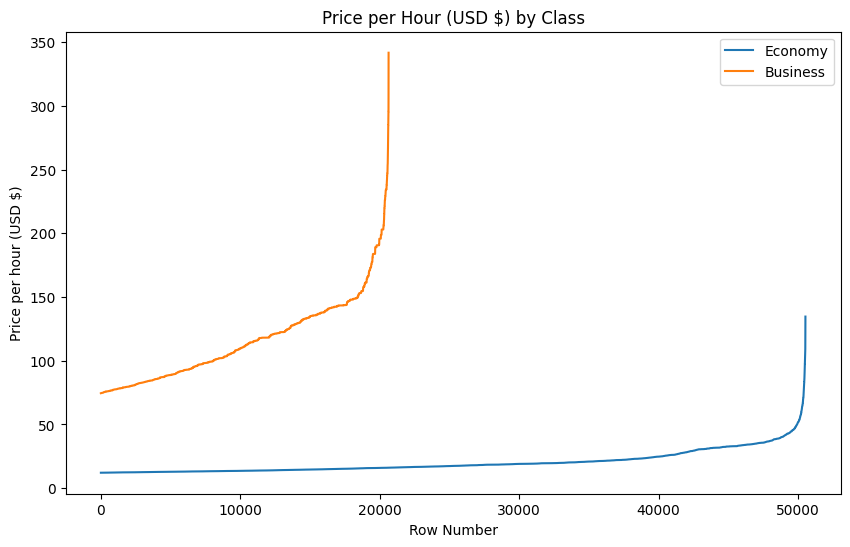

In [115]:
economy_prices_per_hour  = df_cleaned[(df_cleaned['class'] == 'Economy') & (df_cleaned['price per hour (USD $)'] > 12.13)]['price per hour (USD $)'].sort_values().reset_index(drop=True)
business_prices_per_hour = df_cleaned[(df_cleaned['class'] == 'Business') & (df_cleaned['price per hour (USD $)'] > 74.53)]['price per hour (USD $)'].sort_values().reset_index(drop=True)

plt.figure(figsize=(10,6))
plt.plot(range(len(economy_prices_per_hour)), economy_prices_per_hour, label='Economy')
plt.plot(range(len(business_prices_per_hour)), business_prices_per_hour, label='Business')

plt.xlabel('Row Number')
plt.ylabel('Price per hour (USD $)')
plt.title('Price per Hour (USD $) by Class')
plt.legend()
plt.show()

## Clear outliers for price per hour as well.
Let's remove them from our data.

In [116]:
df_cleaned = df_cleaned.drop(df_cleaned[(df_cleaned['class'] == 'Economy') & (df_cleaned['price per hour (USD $)'] > 45)].index)
df_cleaned = df_cleaned.drop(df_cleaned[(df_cleaned['class'] == 'Business') & (df_cleaned['price per hour (USD $)'] > 150)].index)

## Now let's redo the graphs after removing outliers.

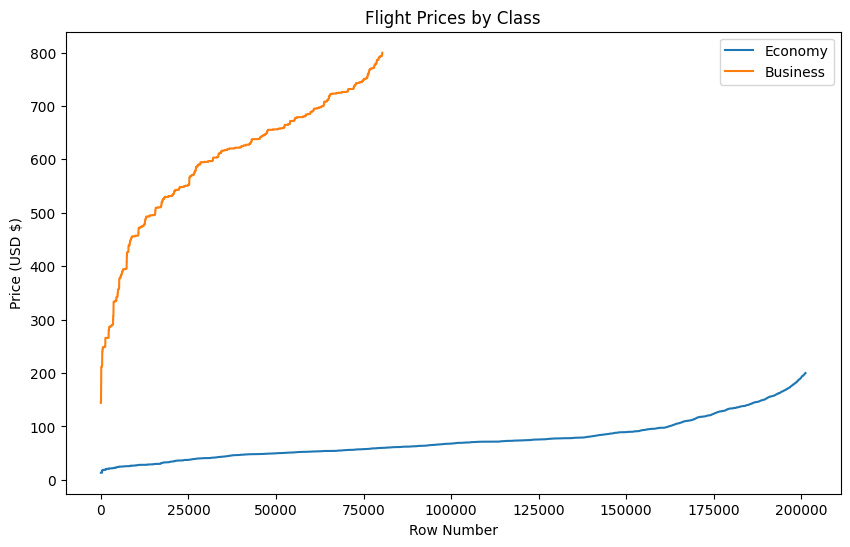

In [118]:
economy_prices  = df_cleaned[df_cleaned['class'] == 'Economy']['price (USD $)'].sort_values().reset_index(drop=True)
business_prices = df_cleaned[df_cleaned['class'] == 'Business']['price (USD $)'].sort_values().reset_index(drop=True)

plt.figure(figsize=(10,6))
plt.plot(range(len(economy_prices)), economy_prices, label='Economy')
plt.plot(range(len(business_prices)), business_prices, label='Business')

plt.xlabel('Row Number')
plt.ylabel('Price (USD $)')
plt.title('Flight Prices by Class')
plt.legend()
plt.show()

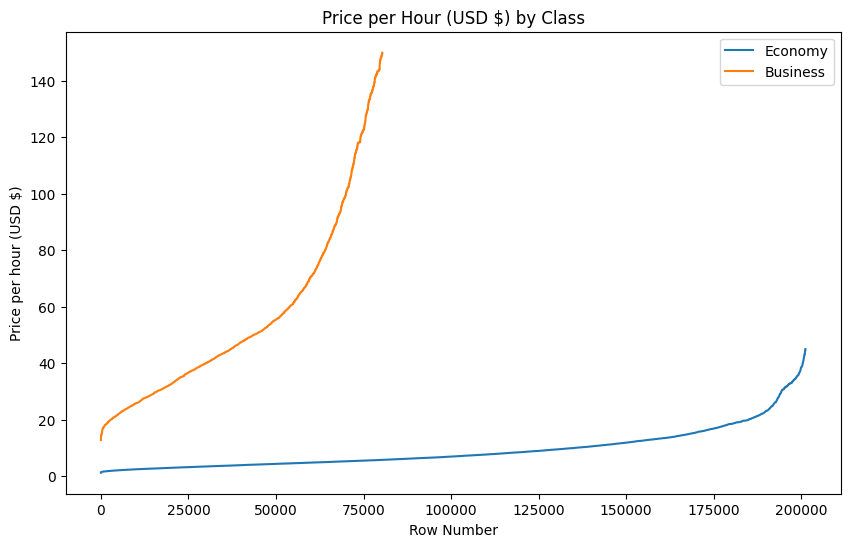

In [119]:
economy_prices_per_hour  = df_cleaned[df_cleaned['class'] == 'Economy']['price per hour (USD $)'].sort_values().reset_index(drop=True)
business_prices_per_hour = df_cleaned[df_cleaned['class'] == 'Business']['price per hour (USD $)'].sort_values().reset_index(drop=True)

plt.figure(figsize=(10,6))
plt.plot(range(len(economy_prices_per_hour)), economy_prices_per_hour, label='Economy')
plt.plot(range(len(business_prices_per_hour)), business_prices_per_hour, label='Business')

plt.xlabel('Row Number')
plt.ylabel('Price per hour (USD $)')
plt.title('Price per Hour (USD $) by Class')
plt.legend()
plt.show()

## Much better, now we can move onto the modeling the data.